# Step 1: Project Overview and Dataset Loading

**Project title:** Mini MLOps Pipeline Design for Online Transportation Fare Estimation Based on Trip and Weather Data

This project studies how online transportation fares can be estimated from trip data and supporting weather data. The main objective is to understand the available data before building a machine learning model.

This case is relevant for a Data Mining and MLOps mini project because fare estimation uses real-world structured data, has a clear numerical prediction target, and needs repeatable validation before data is used in later pipeline stages.

Dataset files used in this notebook:

- `data/raw/cab_rides.csv`: trip records, fare price, distance, service type, route, and identifiers.
- `data/raw/weather.csv`: weather records by location and timestamp.

This notebook only performs data understanding and data audit. It does not train a machine learning model and does not modify the raw data files.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

project_root = Path.cwd()
if not (project_root / "data" / "raw").exists():
    project_root = project_root.parent

cab_rides_path = project_root / "data" / "raw" / "cab_rides.csv"
weather_path = project_root / "data" / "raw" / "weather.csv"

print("Cab rides path:", cab_rides_path)
print("Weather path:", weather_path)


Cab rides path: d:\Tugas Kuliah\SEM 6\Proyek Data Mining\mlops-tarif-transportasi-online\data\raw\cab_rides.csv
Weather path: d:\Tugas Kuliah\SEM 6\Proyek Data Mining\mlops-tarif-transportasi-online\data\raw\weather.csv


In [2]:
cab_rides = pd.read_csv(cab_rides_path)
weather = pd.read_csv(weather_path)

print("First 5 rows of cab_rides.csv")
display(cab_rides.head())

print("First 5 rows of weather.csv")
display(weather.head())


First 5 rows of cab_rides.csv


,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
0,0.44,Lyft,1544952607890,North Station,Haymarket Square,5.0,1.0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared
1,0.44,Lyft,1543284023677,North Station,Haymarket Square,11.0,1.0,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux
2,0.44,Lyft,1543366822198,North Station,Haymarket Square,7.0,1.0,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft
3,0.44,Lyft,1543553582749,North Station,Haymarket Square,26.0,1.0,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL
4,0.44,Lyft,1543463360223,North Station,Haymarket Square,9.0,1.0,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL


First 5 rows of weather.csv


,temp,location,clouds,pressure,rain,time_stamp,humidity,wind
0,42.42,Back Bay,1.0,1012.14,0.1228,1545003901,0.77,11.25
1,42.43,Beacon Hill,1.0,1012.15,0.1846,1545003901,0.76,11.32
2,42.50,Boston University,1.0,1012.15,0.1089,1545003901,0.76,11.07
3,42.11,Fenway,1.0,1012.13,0.0969,1545003901,0.77,11.09
4,43.13,Financial District,1.0,1012.14,0.1786,1545003901,0.75,11.49


In [3]:
dataset_shapes = pd.DataFrame({
    "Dataset": ["cab_rides", "weather"],
    "Rows": [cab_rides.shape[0], weather.shape[0]],
    "Columns": [cab_rides.shape[1], weather.shape[1]],
})

display(dataset_shapes)


,Dataset,Rows,Columns
0,cab_rides,693071,10
1,weather,6276,8


# Step 2: Dataset Structure and Schema Inspection

Before building an MLOps pipeline, we need to understand the columns, data types, and dataset size. This helps us decide which columns can be used directly, which columns need cleaning, and which checks should be automated later.

The trip data and weather data have different roles:

- Trip data describes the ride request, such as distance, cab type, route, product name, and price.
- Weather data describes external conditions, such as temperature, humidity, wind, pressure, clouds, and rain.

At this stage, the datasets are inspected separately. Weather data is not merged with trip data yet.


In [4]:
print("Cab rides columns:")
display(pd.DataFrame({"column_name": cab_rides.columns}))

print("Weather columns:")
display(pd.DataFrame({"column_name": weather.columns}))


Cab rides columns:


,column_name
0,distance
1,cab_type
2,time_stamp
3,destination
4,source
5,price
6,surge_multiplier
7,id
8,product_id
9,name


Weather columns:


,column_name
0,temp
1,location
2,clouds
3,pressure
4,rain
5,time_stamp
6,humidity
7,wind


In [5]:
print("Cab rides data types:")
display(cab_rides.dtypes.rename("data_type").reset_index().rename(columns={"index": "column_name"}))

print("Weather data types:")
display(weather.dtypes.rename("data_type").reset_index().rename(columns={"index": "column_name"}))


Cab rides data types:


,column_name,data_type
0,distance,float64
1,cab_type,object
2,time_stamp,int64
3,destination,object
4,source,object
5,price,float64
6,surge_multiplier,float64
7,id,object
8,product_id,object
9,name,object


Weather data types:


,column_name,data_type
0,temp,float64
1,location,object
2,clouds,float64
3,pressure,float64
4,rain,float64
5,time_stamp,int64
6,humidity,float64
7,wind,float64


In [6]:
print("Cab rides info:")
cab_rides.info()

print("\nWeather info:")
weather.info()


Cab rides info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 693071 entries, 0 to 693070
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   distance          693071 non-null  float64
 1   cab_type          693071 non-null  object 
 2   time_stamp        693071 non-null  int64  
 3   destination       693071 non-null  object 
 4   source            693071 non-null  object 
 5   price             637976 non-null  float64
 6   surge_multiplier  693071 non-null  float64
 7   id                693071 non-null  object 
 8   product_id        693071 non-null  object 
 9   name              693071 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 52.9+ MB

Weather info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6276 entries, 0 to 6275
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   temp        6276 non-null 

In [7]:
print("Cab rides basic statistics:")
display(cab_rides.describe(include="all").T)

print("Weather basic statistics:")
display(weather.describe(include="all").T)


Cab rides basic statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
distance,693071.0,NaN,NaN,NaN,2.18943,1.138937,0.02,1.28,2.16,2.92,7.86
cab_type,693071,2,Uber,385663,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time_stamp,693071.0,NaN,NaN,NaN,1544045709764.357178,689192492.400411,1543203646318.0,1543443968356.5,1543737477529.0,1544827508976.5,1545160510943.0
destination,693071,12,Financial District,58851,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source,693071,12,Financial District,58857,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,637976.0,NaN,NaN,NaN,16.545125,9.324359,2.5,9.0,13.5,22.5,97.5
surge_multiplier,693071.0,NaN,NaN,NaN,1.01387,0.091641,1.0,1.0,1.0,1.0,3.0
id,693071,693071,e7fdc087-fe86-40a5-a3c3-3b2a8badcbda,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_id,693071,13,6f72dfc5-27f1-42e8-84db-ccc7a75f6969,55096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,693071,13,UberXL,55096,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Weather basic statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
temp,6276.0,NaN,NaN,NaN,39.090475,6.022055,19.62,36.0775,40.13,42.8325,55.41
location,6276,12,Back Bay,523,NaN,NaN,NaN,NaN,NaN,NaN,NaN
clouds,6276.0,NaN,NaN,NaN,0.677777,0.314284,0.0,0.44,0.78,0.97,1.0
pressure,6276.0,NaN,NaN,NaN,1008.445209,12.870775,988.25,997.7475,1007.66,1018.48,1035.12
rain,894.0,NaN,NaN,NaN,0.057652,0.100758,0.0002,0.0049,0.01485,0.060925,0.7807
time_stamp,6276.0,NaN,NaN,NaN,1543857377.146431,665933.983457,1543203644.0,1543386870.0,1543513974.0,1544690701.0,1545158702.0
humidity,6276.0,NaN,NaN,NaN,0.763985,0.12734,0.45,0.67,0.76,0.89,0.99
wind,6276.0,NaN,NaN,NaN,6.802812,3.633466,0.29,3.5175,6.57,9.92,18.18


In [8]:
cab_numeric_columns = cab_rides.select_dtypes(include=np.number).columns.tolist()
cab_categorical_columns = cab_rides.select_dtypes(exclude=np.number).columns.tolist()

weather_numeric_columns = weather.select_dtypes(include=np.number).columns.tolist()
weather_categorical_columns = weather.select_dtypes(exclude=np.number).columns.tolist()

print("Cab rides numerical columns:", cab_numeric_columns)
print("Cab rides categorical columns:", cab_categorical_columns)
print("Weather numerical columns:", weather_numeric_columns)
print("Weather categorical columns:", weather_categorical_columns)


Cab rides numerical columns: ['distance', 'time_stamp', 'price', 'surge_multiplier']
Cab rides categorical columns: ['cab_type', 'destination', 'source', 'id', 'product_id', 'name']
Weather numerical columns: ['temp', 'clouds', 'pressure', 'rain', 'time_stamp', 'humidity', 'wind']
Weather categorical columns: ['location']


In [9]:
def create_schema_summary(df, dataset_name):
    return pd.DataFrame({
        "dataset": dataset_name,
        "column_name": df.columns,
        "data_type": [str(dtype) for dtype in df.dtypes],
        "missing_values": df.isna().sum().values,
        "unique_values": df.nunique(dropna=True).values,
    })

schema_summary = pd.concat([
    create_schema_summary(cab_rides, "cab_rides"),
    create_schema_summary(weather, "weather"),
], ignore_index=True)

display(schema_summary)


,dataset,column_name,data_type,missing_values,unique_values
0,cab_rides,distance,float64,0,549
1,cab_rides,cab_type,object,0,2
2,cab_rides,time_stamp,int64,0,114335
3,cab_rides,destination,object,0,12
4,cab_rides,source,object,0,12
5,cab_rides,price,float64,55095,147
6,cab_rides,surge_multiplier,float64,0,7
7,cab_rides,id,object,0,693071
8,cab_rides,product_id,object,0,13
9,cab_rides,name,object,0,13


# Step 3: Target and Feature Understanding

The main prediction target for this project is `price`. Because `price` is a numerical fare value, this project is a **regression** problem.

Possible input features from the trip data include `distance`, `cab_type`, `source`, `destination`, `name`, `time_stamp`, and `surge_multiplier`. Weather-related features such as `temp`, `clouds`, `pressure`, `rain`, `humidity`, and `wind` may be useful in a later step after careful time and location alignment.

Some columns should not be used directly as model features. For example, `id` and `product_id` are identifiers. They may uniquely describe a record or product code, but they do not represent general ride behavior in a clean way for a first model.


In [10]:
target_column = "price"

if target_column in cab_rides.columns:
    print("Target column 'price' exists in cab_rides.csv.")
else:
    print("Target column 'price' is missing. This must be fixed before modeling.")


Target column 'price' exists in cab_rides.csv.


In [11]:
missing_price_rows = cab_rides["price"].isna().sum()
missing_price_pct = missing_price_rows / len(cab_rides) * 100

print(f"Rows with missing price: {missing_price_rows:,}")
print(f"Percentage of missing price: {missing_price_pct:.2f}%")


Rows with missing price: 55,095
Percentage of missing price: 7.95%


Price distribution using basic statistics:


,price
count,637976.000000
mean,16.545125
std,9.324359
min,2.500000
25%,9.000000
50%,13.500000
75%,22.500000
max,97.500000


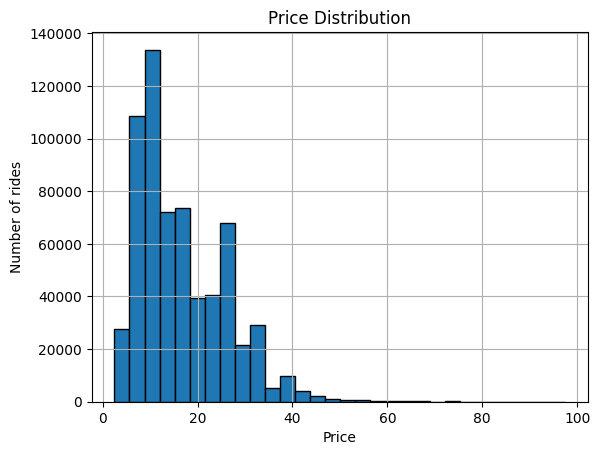

In [12]:
print("Price distribution using basic statistics:")
display(cab_rides["price"].describe().to_frame("price"))

cab_rides["price"].dropna().hist(bins=30, edgecolor="black")
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of rides")
plt.show()


Distance distribution using basic statistics:


,distance
count,693071.000000
mean,2.189430
std,1.138937
min,0.020000
25%,1.280000
50%,2.160000
75%,2.920000
max,7.860000


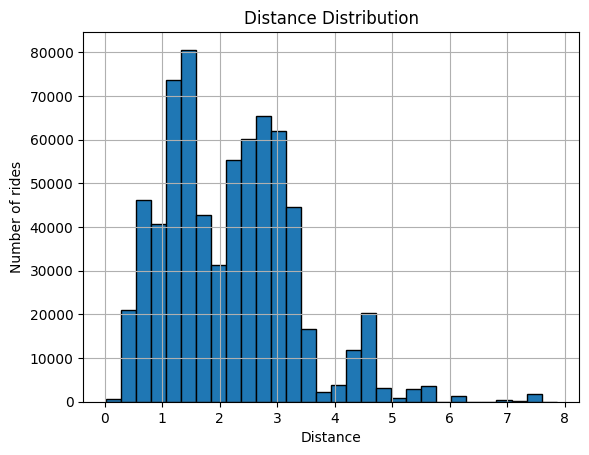

In [13]:
print("Distance distribution using basic statistics:")
display(cab_rides["distance"].describe().to_frame("distance"))

cab_rides["distance"].dropna().hist(bins=30, edgecolor="black")
plt.title("Distance Distribution")
plt.xlabel("Distance")
plt.ylabel("Number of rides")
plt.show()


In [14]:
for column in ["cab_type", "source", "destination", "name"]:
    print(f"Value counts for {column}:")
    display(cab_rides[column].value_counts(dropna=False).rename_axis(column).reset_index(name="count"))


Value counts for cab_type:


,cab_type,count
0,Uber,385663
1,Lyft,307408


Value counts for source:


,source,count
0,Financial District,58857
1,Theatre District,57813
2,Back Bay,57792
3,Boston University,57764
4,North End,57763
5,Fenway,57757
6,Northeastern University,57756
7,South Station,57750
8,Haymarket Square,57736
9,West End,57562


Value counts for destination:


,destination,count
0,Financial District,58851
1,Theatre District,57798
2,Back Bay,57780
3,Haymarket Square,57764
4,Boston University,57764
5,Fenway,57757
6,North End,57756
7,Northeastern University,57755
8,South Station,57749
9,West End,57575


Value counts for name:


,name,count
0,UberXL,55096
1,WAV,55096
2,Black SUV,55096
3,Black,55095
4,Taxi,55095
5,UberX,55094
6,UberPool,55091
7,Lux,51235
8,Lux Black XL,51235
9,Lyft,51235


In [15]:
valid_price_distance = cab_rides.dropna(subset=["price", "distance"]).copy()
valid_price_distance["distance_bin"] = pd.cut(valid_price_distance["distance"], bins=10)

distance_price_summary = (
    valid_price_distance
    .groupby("distance_bin", observed=True)
    .agg(
        ride_count=("price", "size"),
        average_distance=("distance", "mean"),
        average_price=("price", "mean"),
        median_price=("price", "median"),
    )
    .reset_index()
)

display(distance_price_summary)


,distance_bin,ride_count,average_distance,average_price,median_price
0,"(0.0122, 0.804]",62244,0.582350,12.517959,10.5
1,"(0.804, 1.588]",179352,1.254399,13.632071,12.0
2,"(1.588, 2.372]",118614,2.009127,15.998349,14.0
3,"(2.372, 3.156]",172412,2.771393,18.083805,16.5
4,"(3.156, 3.94]",59094,3.340930,20.293411,19.5
5,"(3.94, 4.724]",33216,4.451817,23.434620,22.5
6,"(4.724, 5.508]",6714,5.080143,25.910262,26.0
7,"(5.508, 6.292]",4176,5.777126,25.139368,21.5
8,"(6.292, 7.076]",354,6.913220,26.937853,24.0
9,"(7.076, 7.86]",1800,7.420033,27.605556,25.0


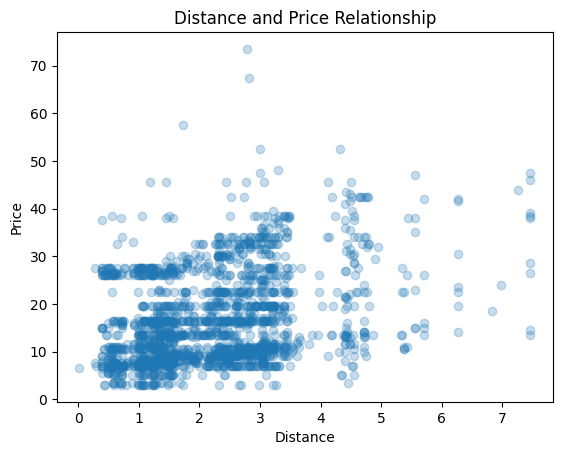

In [16]:
plot_sample = valid_price_distance.sample(n=min(2000, len(valid_price_distance)), random_state=42)

plt.scatter(plot_sample["distance"], plot_sample["price"], alpha=0.25)
plt.title("Distance and Price Relationship")
plt.xlabel("Distance")
plt.ylabel("Price")
plt.show()


# Step 4: Data Quality Audit and Validation Checks

Data validation is part of the Continuous Integration (CI) phase in an MLOps pipeline. Before training, the system should check whether the data is complete, logical, and safe to process.

Examples of invalid data for this project include missing `price`, `distance` less than or equal to zero, `price` less than or equal to zero, missing `source`, missing `destination`, missing `cab_type`, and missing `name`.

These checks help prevent poor-quality data from entering the next pipeline step.


In [17]:
print("Total missing values per column in cab_rides:")
display(cab_rides.isna().sum().sort_values(ascending=False).rename("missing_values").reset_index().rename(columns={"index": "column_name"}))

print("Total missing values per column in weather:")
display(weather.isna().sum().sort_values(ascending=False).rename("missing_values").reset_index().rename(columns={"index": "column_name"}))


Total missing values per column in cab_rides:


,column_name,missing_values
0,price,55095
1,distance,0
2,cab_type,0
3,time_stamp,0
4,destination,0
5,source,0
6,surge_multiplier,0
7,id,0
8,product_id,0
9,name,0


Total missing values per column in weather:


,column_name,missing_values
0,rain,5382
1,temp,0
2,clouds,0
3,location,0
4,pressure,0
5,time_stamp,0
6,humidity,0
7,wind,0


In [18]:
duplicate_summary = pd.DataFrame({
    "Dataset": ["cab_rides", "weather"],
    "Duplicate Rows": [cab_rides.duplicated().sum(), weather.duplicated().sum()],
})

display(duplicate_summary)


,Dataset,Duplicate Rows
0,cab_rides,0
1,weather,0


In [19]:
row_checks = {
    "Missing price": cab_rides["price"].isna(),
    "Distance <= 0": cab_rides["distance"] <= 0,
    "Price <= 0": cab_rides["price"] <= 0,
    "Missing source": cab_rides["source"].isna(),
    "Missing destination": cab_rides["destination"].isna(),
    "Missing cab_type": cab_rides["cab_type"].isna(),
    "Missing name": cab_rides["name"].isna(),
}

row_check_summary = pd.DataFrame({
    "Check Name": list(row_checks.keys()),
    "Failed Rows": [int(mask.sum()) for mask in row_checks.values()],
})

display(row_check_summary)


,Check Name,Failed Rows
0,Missing price,55095
1,Distance <= 0,0
2,Price <= 0,0
3,Missing source,0
4,Missing destination,0
5,Missing cab_type,0
6,Missing name,0


In [20]:
def missing_percentage_table(df, dataset_name):
    missing_count = df.isna().sum()
    missing_percentage = missing_count / len(df) * 100
    return pd.DataFrame({
        "dataset": dataset_name,
        "column_name": df.columns,
        "missing_values": missing_count.values,
        "missing_percentage": missing_percentage.round(2).values,
    })

missing_percentage_summary = pd.concat([
    missing_percentage_table(cab_rides, "cab_rides"),
    missing_percentage_table(weather, "weather"),
], ignore_index=True)

display(missing_percentage_summary)


,dataset,column_name,missing_values,missing_percentage
0,cab_rides,distance,0,0.00
1,cab_rides,cab_type,0,0.00
2,cab_rides,time_stamp,0,0.00
3,cab_rides,destination,0,0.00
4,cab_rides,source,0,0.00
5,cab_rides,price,55095,7.95
6,cab_rides,surge_multiplier,0,0.00
7,cab_rides,id,0,0.00
8,cab_rides,product_id,0,0.00
9,cab_rides,name,0,0.00


In [21]:
def status_from_count(failed_rows, issue_status):
    if failed_rows == 0:
        return "PASS"
    return issue_status

price_column_failed = 0 if "price" in cab_rides.columns else len(cab_rides)
missing_price_failed = int(cab_rides["price"].isna().sum()) if "price" in cab_rides.columns else len(cab_rides)
price_le_zero_failed = int((cab_rides["price"] <= 0).sum()) if "price" in cab_rides.columns else len(cab_rides)
weather_rain_missing = int(weather["rain"].isna().sum()) if "rain" in weather.columns else 0

validation_summary = pd.DataFrame([
    {
        "Check Name": "Target column exists",
        "Rule": "Column 'price' must exist in cab_rides",
        "Failed Rows": price_column_failed,
        "Status": status_from_count(price_column_failed, "FAIL"),
        "Recommendation": "Keep 'price' as the supervised learning target.",
    },
    {
        "Check Name": "Missing price",
        "Rule": "Price should be available for training rows",
        "Failed Rows": missing_price_failed,
        "Status": status_from_count(missing_price_failed, "WARNING"),
        "Recommendation": "Remove rows with missing target before model training.",
    },
    {
        "Check Name": "Distance validity",
        "Rule": "Distance must be greater than 0",
        "Failed Rows": int((cab_rides["distance"] <= 0).sum()),
        "Status": status_from_count(int((cab_rides["distance"] <= 0).sum()), "FAIL"),
        "Recommendation": "Investigate or remove invalid distance rows if found.",
    },
    {
        "Check Name": "Price validity",
        "Rule": "Price must be greater than 0 when present",
        "Failed Rows": price_le_zero_failed,
        "Status": status_from_count(price_le_zero_failed, "FAIL"),
        "Recommendation": "Investigate impossible fare values if found.",
    },
    {
        "Check Name": "Missing source",
        "Rule": "Source should not be missing",
        "Failed Rows": int(cab_rides["source"].isna().sum()),
        "Status": status_from_count(int(cab_rides["source"].isna().sum()), "FAIL"),
        "Recommendation": "Fill only if business rules are clear; otherwise remove affected rows.",
    },
    {
        "Check Name": "Missing destination",
        "Rule": "Destination should not be missing",
        "Failed Rows": int(cab_rides["destination"].isna().sum()),
        "Status": status_from_count(int(cab_rides["destination"].isna().sum()), "FAIL"),
        "Recommendation": "Fill only if business rules are clear; otherwise remove affected rows.",
    },
    {
        "Check Name": "Missing cab_type",
        "Rule": "Cab type should not be missing",
        "Failed Rows": int(cab_rides["cab_type"].isna().sum()),
        "Status": status_from_count(int(cab_rides["cab_type"].isna().sum()), "FAIL"),
        "Recommendation": "Investigate missing service platform values if found.",
    },
    {
        "Check Name": "Missing name",
        "Rule": "Ride product name should not be missing",
        "Failed Rows": int(cab_rides["name"].isna().sum()),
        "Status": status_from_count(int(cab_rides["name"].isna().sum()), "WARNING"),
        "Recommendation": "Handle missing product names before categorical encoding.",
    },
    {
        "Check Name": "Duplicate cab rows",
        "Rule": "Exact duplicate rows should be reviewed",
        "Failed Rows": int(cab_rides.duplicated().sum()),
        "Status": status_from_count(int(cab_rides.duplicated().sum()), "WARNING"),
        "Recommendation": "Remove duplicates only after confirming they are not valid repeated rides.",
    },
    {
        "Check Name": "Missing weather rain",
        "Rule": "Rain should be reviewed before using weather features",
        "Failed Rows": weather_rain_missing,
        "Status": status_from_count(weather_rain_missing, "WARNING"),
        "Recommendation": "Check whether missing rain means no rain, then fill with 0 if appropriate.",
    },
])

display(validation_summary)


,Check Name,Rule,Failed Rows,Status,Recommendation
0,Target column exists,Column 'price' must exist in cab_rides,0,PASS,Keep 'price' as the supervised learning target.
1,Missing price,Price should be available for training rows,55095,WARNING,Remove rows with missing target before model t...
2,Distance validity,Distance must be greater than 0,0,PASS,Investigate or remove invalid distance rows if...
3,Price validity,Price must be greater than 0 when present,0,PASS,Investigate impossible fare values if found.
4,Missing source,Source should not be missing,0,PASS,Fill only if business rules are clear; otherwi...
5,Missing destination,Destination should not be missing,0,PASS,Fill only if business rules are clear; otherwi...
6,Missing cab_type,Cab type should not be missing,0,PASS,Investigate missing service platform values if...
7,Missing name,Ride product name should not be missing,0,PASS,Handle missing product names before categorica...
8,Duplicate cab rows,Exact duplicate rows should be reviewed,0,PASS,Remove duplicates only after confirming they a...
9,Missing weather rain,Rain should be reviewed before using weather f...,5382,WARNING,"Check whether missing rain means no rain, then..."


# Step 5: Initial Findings and MLOps Preparation Notes

Key findings from this audit:

- The trip dataset contains the target column `price`, so it can support a supervised regression task.
- Some `price` values are missing. These rows should not be used directly for supervised training because the target is unknown.
- The `distance` values are positive in the current data, so the basic distance validation check passes.
- The important route and service columns, such as `source`, `destination`, `cab_type`, and `name`, are complete in the current data.
- The weather dataset is useful for later feature engineering, but it should be aligned carefully by location and time before merging.

The dataset is suitable for the next step after cleaning rows with missing targets and preparing categorical and time-based features.

Recommended initial features from trip data:

- `distance`
- `cab_type`
- `source`
- `destination`
- `name`
- `surge_multiplier`
- `time_stamp`

Columns recommended for exclusion from the first model:

- `id`
- `product_id`
- `price` as an input feature, because it is the target

Recommended cleaning actions for the next notebook:

- Remove rows where `price` is missing before training.
- Convert `time_stamp` into readable datetime features.
- Encode categorical columns such as `cab_type`, `source`, `destination`, and `name`.
- Review missing `rain` values before using weather features.
- Plan a careful weather merge by location and time.

This audit supports later MLOps work:

- CI checklist: automate schema checks, missing-value checks, duplicate checks, and logical validation rules.
- CT checklist: retrain only after the data passes validation and preprocessing is repeatable.
- CD scenario: deploy only a model pipeline that receives valid features and handles expected input formats.


In [22]:
valid_price_rows = int(cab_rides["price"].notna().sum())
missing_price_rows = int(cab_rides["price"].isna().sum())
invalid_distance_rows = int((cab_rides["distance"] <= 0).sum())

final_summary = pd.DataFrame({
    "Metric": [
        "Number of rows in cab_rides",
        "Number of rows in weather",
        "Number of columns in cab_rides",
        "Number of columns in weather",
        "Number of rows with valid price",
        "Number of rows with missing price",
        "Number of invalid distance rows",
        "Recommended target column",
        "Recommended problem type",
    ],
    "Value": [
        f"{len(cab_rides):,}",
        f"{len(weather):,}",
        cab_rides.shape[1],
        weather.shape[1],
        f"{valid_price_rows:,}",
        f"{missing_price_rows:,}",
        f"{invalid_distance_rows:,}",
        "price",
        "Regression",
    ],
})

display(final_summary)

print("Final short summary")
for _, row in final_summary.iterrows():
    print(f"{row['Metric']}: {row['Value']}")


,Metric,Value
0,Number of rows in cab_rides,"693,071"
1,Number of rows in weather,"6,276"
2,Number of columns in cab_rides,10
3,Number of columns in weather,8
4,Number of rows with valid price,"637,976"
5,Number of rows with missing price,"55,095"
6,Number of invalid distance rows,0
7,Recommended target column,price
8,Recommended problem type,Regression


Final short summary
Number of rows in cab_rides: 693,071
Number of rows in weather: 6,276
Number of columns in cab_rides: 10
Number of columns in weather: 8
Number of rows with valid price: 637,976
Number of rows with missing price: 55,095
Number of invalid distance rows: 0
Recommended target column: price
Recommended problem type: Regression
